In [1]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, MinMaxScaler, TargetEncoder
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from helper import *
from plots import *
import random

In [3]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

## 1. Предобработка

In [4]:
df = pd.read_csv('diamonds.csv')

In [5]:
# Общие преобразования
df_preprocessed = df.copy()

In [6]:
df_preprocessed = df_preprocessed.drop(columns=['Unnamed: 0'])

In [7]:
# удалим строки с нулевыми значениями x,y или z
df_preprocessed = df_preprocessed.query("~(x == 0) & ~(y == 0) & ~(z == 0)")

In [8]:
# делим данные на признаки и таргет
X, y = divide_data(df_preprocessed, 'price')

In [9]:
categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

In [10]:
# Будем использовать порядковое кодирование. Для этого выпишем все категории для каждого столбца в порядке увеличения номера
category_orders = [
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'],                     
    ['J', 'I', 'H', 'G','F','E','D'],
    ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
]


In [11]:
# Создаем предобработчик данных в виде последовательного Pipeline
preprocessor = Pipeline([
    ('transformations', ColumnTransformer(
        [('encoder', OrdinalEncoder(categories=category_orders), categorical_cols)],
        remainder='passthrough',  # числовые колонки передаются без изменений
        verbose_feature_names_out=False
    ))
])

# Устанавливаем вывод в формате pandas DataFrame (для sklearn версии 1.0 и выше)
preprocessor.set_output(transform="pandas")

Pipeline(steps=[('transformations',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder',
                                                  OrdinalEncoder(categories=[['Fair',
                                                                              'Good',
                                                                              'Very '
                                                                              'Good',
                                                                              'Premium',
                                                                              'Ideal'],
                                                                             ['J',
                                                                              'I',
                                                                              'H',
                                                                              'G',
                                                                              'F',
                                                                              'E',
                                                                              'D'],
                                                                             ['I1',
                                                                              'SI2',
                                                                              'SI1',
                                                                              'VS2',
                                                                              'VS1',
                                                                              'VVS2',
                                                                              'VVS1',
                                                                              'IF']]),
                                                  ['cut', 'color', 'clarity'])],
                                   verbose_feature_names_out=False))])

In [12]:
# сохраним все бейслайн модели в виде списка для удобства
models = [
    ('SGDRegression', SGDRegressor(random_state=SEED, max_iter=1000)),
    ('DecisionTreeRegressor', DecisionTreeRegressor(random_state=SEED, max_depth=8)),
    ('RandomForestRegressor', RandomForestRegressor(random_state=SEED)),
    ('LGBMRegressor', LGBMRegressor(random_state=SEED))
]

In [13]:
# используем 5-блочную кросс-валидацию
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000303 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

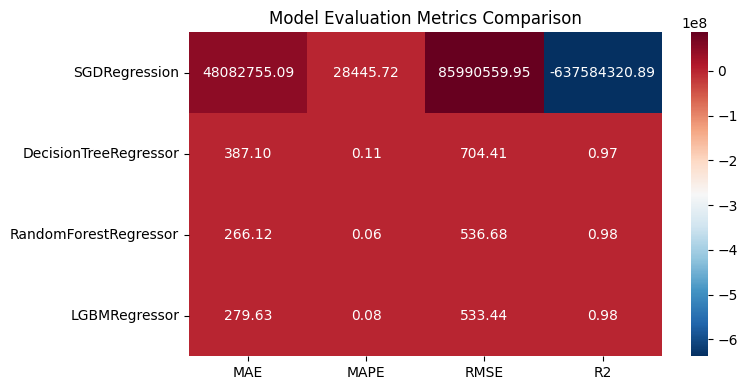

In [14]:
initial_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

## 2. Преобразования данных и feature engineering

### 2.1 Применение StandardScaler (стандартизация)

#### 2.1.1 Без удаления

In [15]:
X_standard_scaler = X.copy()

In [16]:
scaled_columns = ['caratScaled', 'depthScaled', 'tableScaled','xScaled','yScaled','zScaled']
X_standard_scaler[scaled_columns] = X_standard_scaler[['carat', 'depth', 'table', 'x', 'y', 'z']]

In [17]:
preprocessor_standard_scaler = clone(preprocessor)

preprocessor_standard_scaler['transformations'].transformers.append(
    ('scaler', StandardScaler(), scaled_columns)
)


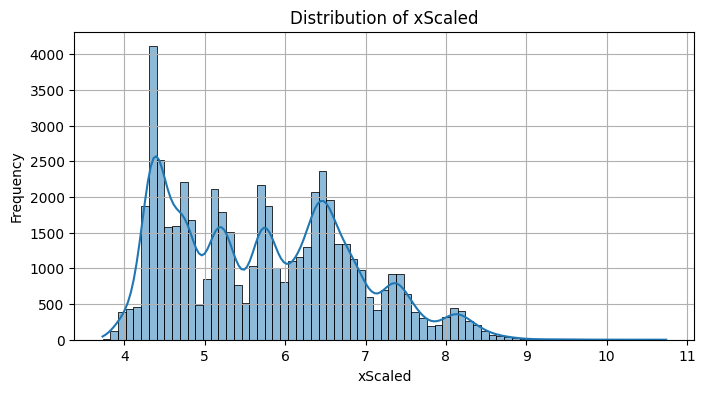

In [18]:
plot_hist_numeric(X_standard_scaler, 'xScaled')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2539
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 15
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2537
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 15
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

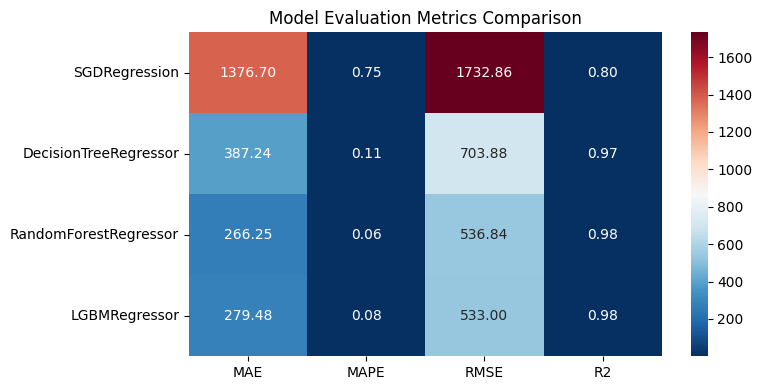

In [19]:
standard_scaler_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_standard_scaler,
    y=y,
    preprocessor=preprocessor_standard_scaler,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression         -4.808138e+07 -28444.973884 -8.598883e+07  6.375843e+08
 DecisionTreeRegressor  1.331904e-01     -0.000011 -5.285683e-01  4.682598e-05
 RandomForestRegressor  1.275307e-01      0.000037  1.558077e-01 -1.059777e-05
 LGBMRegressor         -1.507736e-01      0.000398 -4.408706e-01  2.958981e-05)

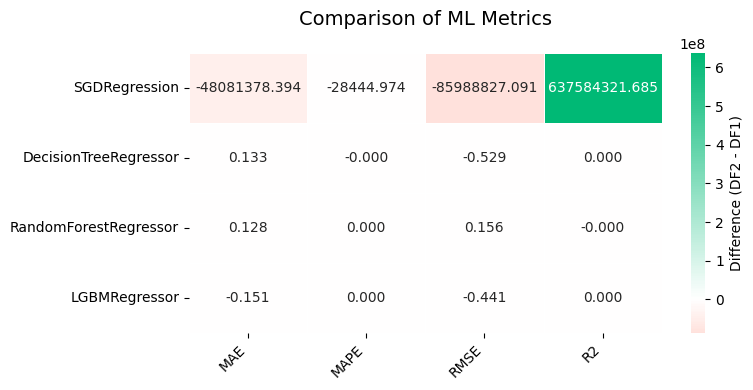

In [20]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics)

Сильно улучшилась линейная регрессия, что ожидаемо, так как она плохо работает с сырыми данными. Остальные модели без изменений. 

#### 2.1.2 С удалением

In [21]:
X_standard_scaler_del = X.copy()

In [22]:
preprocessor_standard_scaler_del = clone(preprocessor)

preprocessor_standard_scaler_del['transformations'].transformers.append(
    ('scaler', StandardScaler(), ['carat', 'depth', 'table', 'x', 'y', 'z'])
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1284
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1281
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

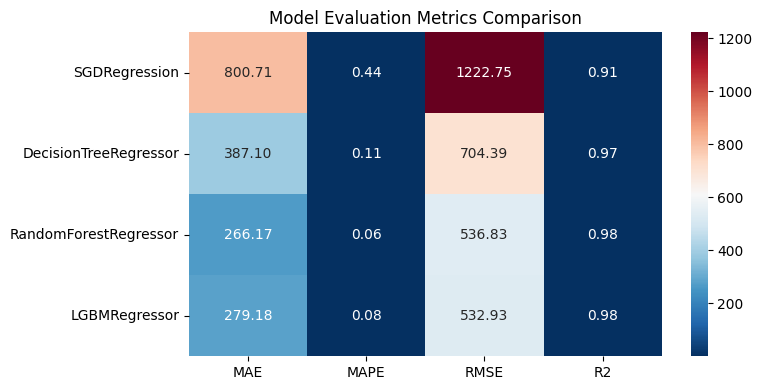

In [23]:
standard_scaler_metrics_del = train_evaluate_models_cv_reg(
    models=models,
    X=X_standard_scaler_del,
    y=y,
    preprocessor=preprocessor_standard_scaler_del,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression         -4.808195e+07 -28445.282821 -8.598934e+07  6.375843e+08
 DecisionTreeRegressor -5.037294e-03     -0.000006 -1.813945e-02  1.529472e-06
 RandomForestRegressor  4.898271e-02      0.000016  1.504007e-01 -1.057335e-05
 LGBMRegressor         -4.494987e-01      0.000007 -5.155046e-01  3.428660e-05)

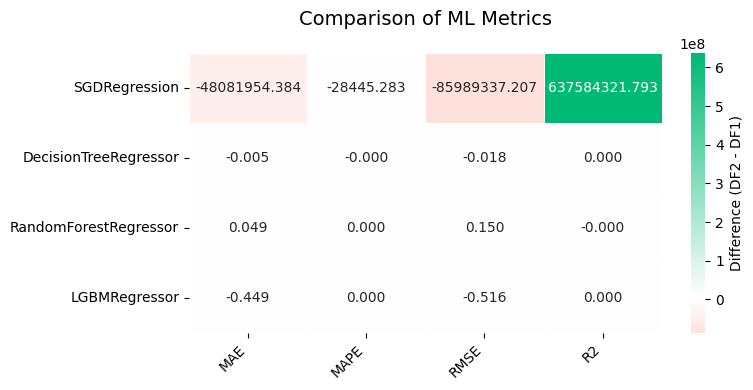

In [24]:
compare_metrics_heatmap(initial_metrics, standard_scaler_metrics_del)

С удалением результаты линейной регрессии стали еще лучше

### 2.2 Нормализация

#### 2.6.1 Без удаления

In [25]:
X_normalised = X.copy()

In [26]:
scaled_columns = ['caratScaled', 'depthScaled', 'tableScaled','xScaled','yScaled','zScaled']
X_normalised[scaled_columns] = X_normalised[['carat', 'depth', 'table', 'x', 'y', 'z']]

In [27]:
preprocessor_normalisation = clone(preprocessor)

preprocessor_normalisation['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), scaled_columns)
)

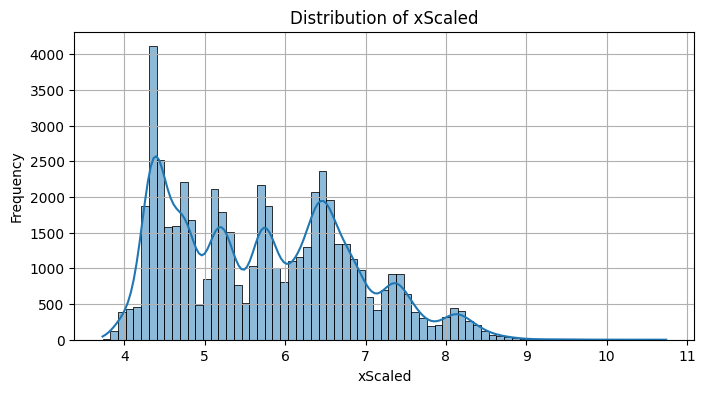

In [28]:
plot_hist_numeric(X_normalised, 'xScaled')

c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
c:\Users\Mikhail\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2528
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 15
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000520 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2531
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 15
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001388 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] To

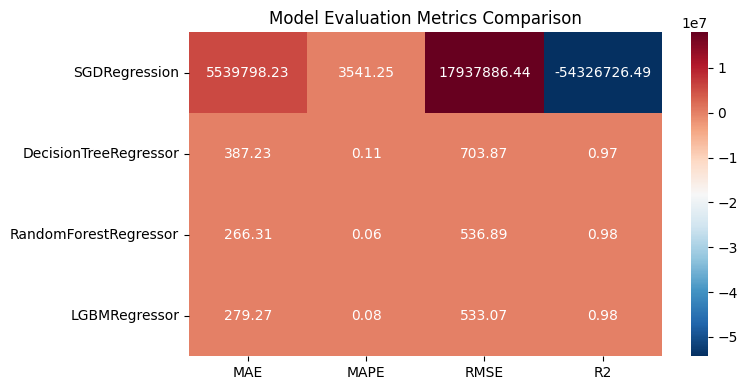

In [29]:
normalised_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_normalised,
    y=y,
    preprocessor=preprocessor_normalisation,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression         -4.254296e+07 -24904.470692 -6.805267e+07  5.832576e+08
 DecisionTreeRegressor  1.226649e-01     -0.000016 -5.368091e-01  4.756784e-05
 RandomForestRegressor  1.897944e-01      0.000042  2.063463e-01 -1.364841e-05
 LGBMRegressor         -3.600498e-01     -0.000085 -3.742236e-01  2.554823e-05)

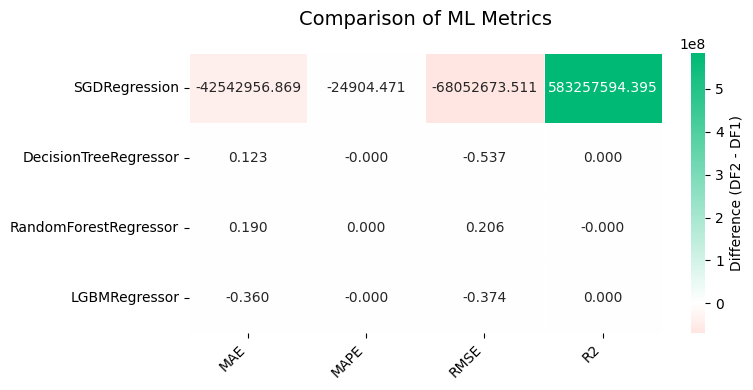

In [30]:
compare_metrics_heatmap(initial_metrics, normalised_metrics)

Регрессия лучше, но все равно плохо.

#### 2.2.2 С удалением

In [31]:
X_normalised_del = X.copy()

In [32]:
preprocessor_normalisation_del = clone(preprocessor)

preprocessor_normalisation_del['transformations'].transformers.append(
    ('scaler', MinMaxScaler(), ['carat', 'depth', 'table', 'x', 'y', 'z'])
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1273
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

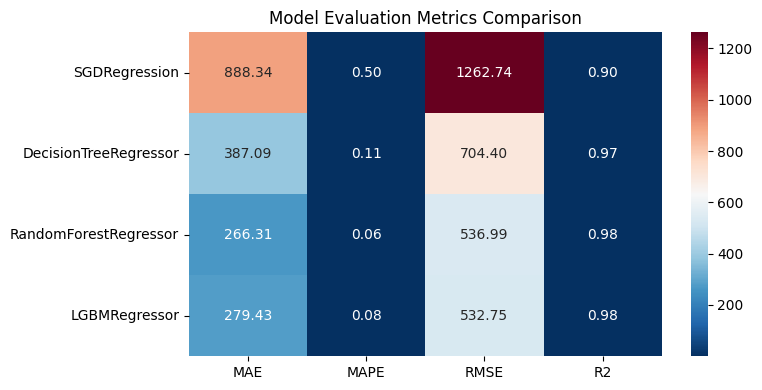

In [33]:
normalised_metrics_del = train_evaluate_models_cv_reg(
    models=models,
    X=X_normalised_del,
    y=y,
    preprocessor=preprocessor_normalisation_del,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression         -4.808187e+07 -28445.216098 -8.598930e+07  6.375843e+08
 DecisionTreeRegressor -8.901859e-03     -0.000007 -7.890986e-03  7.747324e-07
 RandomForestRegressor  1.845660e-01      0.000026  3.088906e-01 -2.060342e-05
 LGBMRegressor         -2.035892e-01      0.000195 -6.980847e-01  4.804279e-05)

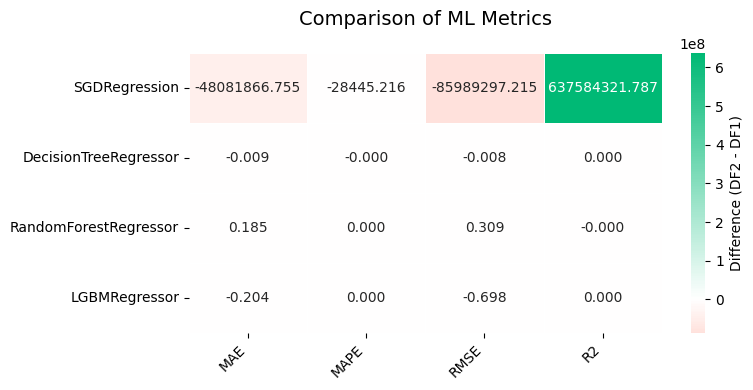

In [34]:
compare_metrics_heatmap(initial_metrics, normalised_metrics_del)

Регрессия сильно улучшилась

### 2.3 Создание новых признаков "xy","xz","yz"

Так как depth линейно зависит от x,y,z , попробуем преобразовать их в другие признаки.  

In [35]:
X_fich = X.copy()

In [36]:
X_fich['xy'] = X_fich['x']/X_fich['y']
X_fich['xz'] = X_fich['x']/X_fich['z']
X_fich['yz'] = X_fich['y']/X_fich['z']
X_fich = X_fich.drop(columns=['x', 'y','z'])

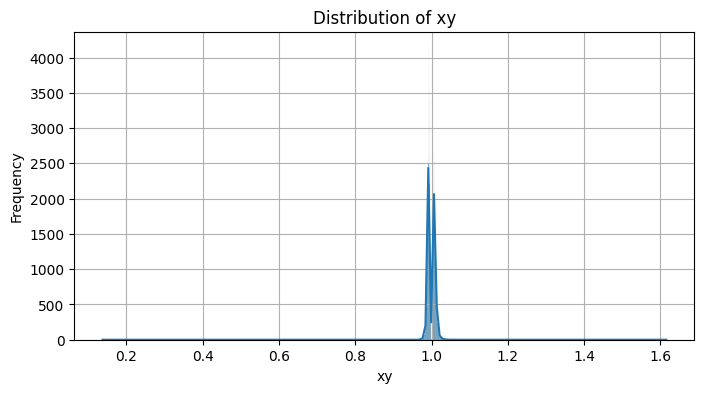

In [37]:
plot_hist_numeric(X_fich, 'xy')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3926.531459
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1276
[LightGBM] [Info] Number of data points in the train set: 43136, number of used features: 9
[LightGBM] [Info] Start training from score 3944.897997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

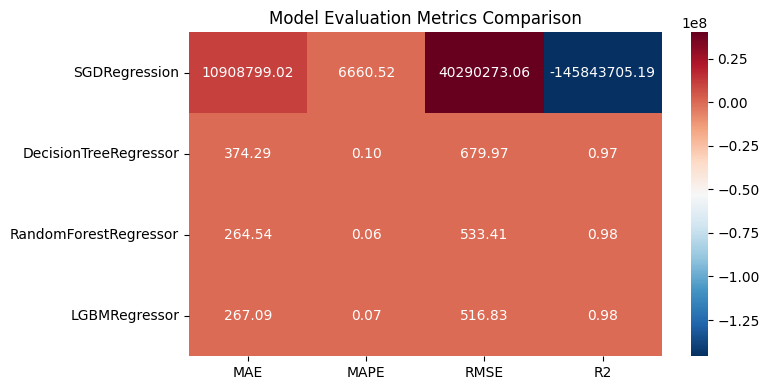

In [38]:
fich_metrics = train_evaluate_models_cv_reg(
    models=models,
    X=X_fich,
    y=y,
    preprocessor=preprocessor,
    cv=cv,
    seed=SEED
)

(<Figure size 800x400 with 2 Axes>,
                                 MAE          MAPE          RMSE            R2
 SGDRegression         -3.717396e+07 -21785.203025 -4.570029e+07  4.917406e+08
 DecisionTreeRegressor -1.280994e+01     -0.006173 -2.443790e+01  2.109334e-03
 RandomForestRegressor -1.587973e+00     -0.003298 -3.265956e+00  2.200847e-04
 LGBMRegressor         -1.254252e+01     -0.009723 -1.661641e+01  1.096238e-03)

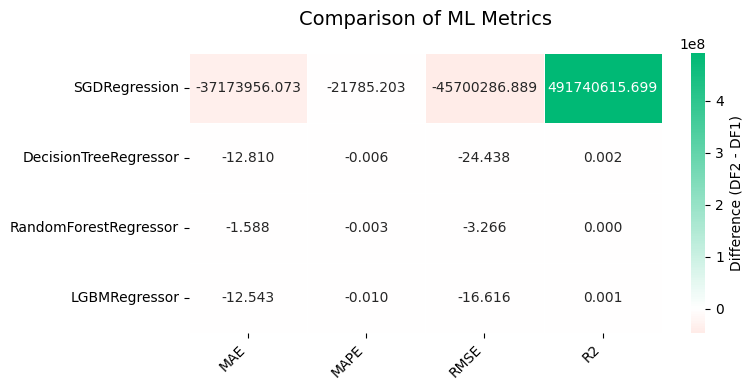

In [39]:
compare_metrics_heatmap(initial_metrics, fich_metrics)

Получили небольшие приросты ко всем моделям